<a href="https://colab.research.google.com/github/Shivani-sree/usd-inr-forex-prediction/blob/main/forex.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

inserting dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving forex.csv.csv to forex.csv (2).csv


reading data

In [ ]:
import pandas as pd

df = pd.read_csv("forex.csv.csv")  # unga file name podu
df.head()

,Date,Open,High,Low,Close,Adj Close
0,12-05-2017,64.389999,64.394997,64.120003,64.360001,64.360001
1,15-05-2017,64.236000,64.236000,64.019997,64.165497,64.165497
2,16-05-2017,64.038300,64.142998,63.990002,64.038300,64.038300
3,17-05-2017,64.035500,64.180000,63.880001,63.900002,63.900002
4,18-05-2017,64.230003,65.139999,64.220001,64.230003,64.230003


checking data

In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1305 entries, 0 to 1304
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1305 non-null   object 
 1   Open       1302 non-null   float64
 2   High       1302 non-null   float64
 3   Low        1302 non-null   float64
 4   Close      1302 non-null   float64
 5   Adj Close  1302 non-null   float64
dtypes: float64(5), object(1)
memory usage: 61.3+ KB


clean data


In [ ]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close'], dtype='object')

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [ ]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Days
0,2017-05-12,64.389999,64.394997,64.120003,64.360001,64.360001,0
1,2017-05-15,64.236000,64.236000,64.019997,64.165497,64.165497,3
2,2017-05-16,64.038300,64.142998,63.990002,64.038300,64.038300,4
3,2017-05-17,64.035500,64.180000,63.880001,63.900002,63.900002,5
4,2017-05-18,64.230003,65.139999,64.220001,64.230003,64.230003,6


graph plot


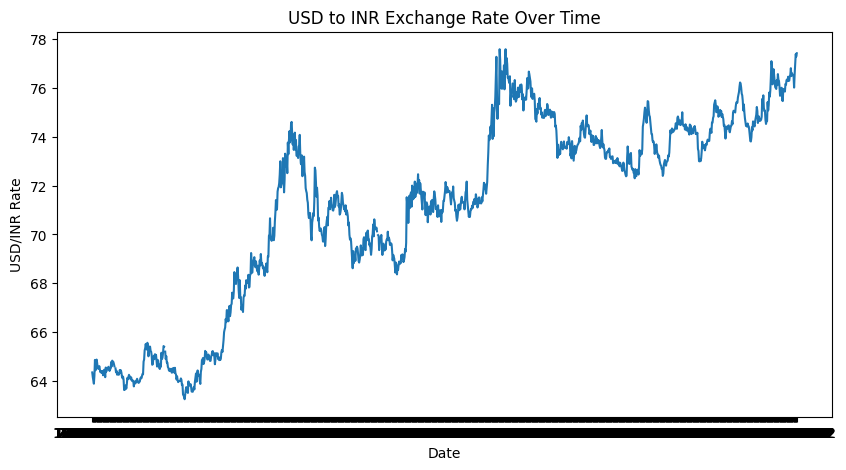

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])
plt.xlabel("Date")
plt.ylabel("USD/INR Rate")
plt.title("USD to INR Exchange Rate Over Time")
plt.show()

to change date format


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values('Date')

In [ ]:
df.head()

,Date,Open,High,Low,Close,Adj Close
0,2017-05-12,64.389999,64.394997,64.120003,64.360001,64.360001
1,2017-05-15,64.236000,64.236000,64.019997,64.165497,64.165497
2,2017-05-16,64.038300,64.142998,63.990002,64.038300,64.038300
3,2017-05-17,64.035500,64.180000,63.880001,63.900002,63.900002
4,2017-05-18,64.230003,65.139999,64.220001,64.230003,64.230003


In [ ]:
df['Days'] = (df['Date'] - df['Date'].min()).dt.days
df.head()

,Date,Open,High,Low,Close,Adj Close,Days
0,2017-05-12,64.389999,64.394997,64.120003,64.360001,64.360001,0
1,2017-05-15,64.236000,64.236000,64.019997,64.165497,64.165497,3
2,2017-05-16,64.038300,64.142998,63.990002,64.038300,64.038300,4
3,2017-05-17,64.035500,64.180000,63.880001,63.900002,63.900002,5
4,2017-05-18,64.230003,65.139999,64.220001,64.230003,64.230003,6


final output stage

In [ ]:
X = df[['Days']]
y = df['Close']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import mean_squared_error

print(mean_squared_error(y_test, y_pred))
print(model.predict([[2000]]))

3.347517377852513
[78.19244083]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


to drop a null values table


In [ ]:
df = df.dropna()

output value last line varies according to given number

In [ ]:
X = df[['Days']]
y = df['Close']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_test, y_pred))

print(model.predict([[100000]]))

4.098445880500596
[723.03328148]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
